# jaxfne — Étude No. 7 · Multi-Trial Continuous Simulation → Spectrolaminar Motif

Run many trials of a canonical column and extract the **spectrolaminar** depth ×
frequency relative-power profile — the deep α/β vs superficial γ motif.

Two caveats, baked into this étude:

- **Synchrony must be low.** A global rhythm (synchrony κ ≳ 0.2) biases the readout
  and masks laminar band structure, so we measure κ and gate on it.
- **The crossover is a regime property.** The deep-α/β vs superficial-γ crossing
  requires band-limited layer-local oscillations while global κ stays low — not
  neuron count or connectivity weight alone (see jaxfne-spectrolaminar-suite).
  appears at scale (≈1k neurons) with band-limited oscillations localized by layer;
  it is not guaranteed at small N.

Built from the package API with the built-in Izhikevich emitter and the canonical
E:I profile. Readouts are `*_proxy` scaffolds; jaxfne is the mathematical backend.

> **Tensor-first alternative:** this notebook defines its circuit via `Configuration` (the original fluent builder). As of 0.4.7, `NeuronalTensor` + `RuntimeConfiguration` is the preferred way to declare a multi-layer/multi-area circuit like this one -- see [`jaxfne_neuronal_tensor_first.ipynb`](../jaxfne_neuronal_tensor_first.ipynb), the [migration guide](../../docs/migration_guide.md), and the [NeuronalTensor API reference](../../docs/api/neuronal_tensor.md). `Configuration` remains fully supported; nothing below needs to change.

In [1]:
import numpy as np
import jaxfne as jtfne
print("jaxfne", jtfne.__version__)

jaxfne 0.4.3


## 1 · Config — editable parameters (the knobs)

In [2]:
N_TOTAL = 1000                 # tutorial-scale; regime + low κ matter more than N alone
DURATION_MS, DT_MS, SEED = 2000.0, 0.5, 0
N_TRIALS = 6
ALPHA_BETA_HZ, GAMMA_HZ = (10.0, 25.0), (40.0, 150.0)
print(f"N={N_TOTAL}  trials={N_TRIALS}  bands: a/b={ALPHA_BETA_HZ} gamma={GAMMA_HZ}")

N=1000  trials=6  bands: a/b=(10.0, 25.0) gamma=(40.0, 150.0)


## 2 · Build the canonical column

In [3]:
cfg = (
    jtfne.build_laminar_column(name="V1", n=N_TOTAL, ei_profile="canonical")
    .runtime(seed=SEED)
    .set_emitter("izhikevich", "cortical_eig")
    .probes(["spikes", "V_m", "LFP", "CSD"], n_contacts=16)
    .field(domain="laminar_column", conductivity="proxy", boundary="mean_zero_neumann")
)
model = jtfne.construct(cfg)
print(f"built {N_TOTAL}-neuron canonical column")

built 1000-neuron canonical column


## 3 · Synchrony check — the trust gate

Spectrolaminar relative power is only interpretable in the asynchronous-irregular
regime; measure κ on a representative simulation before trusting the motif.

In [4]:
sig = jtfne.simulate(model, sim=jtfne.Simulation(
    duration_ms=DURATION_MS, dt_ms=DT_MS, seed=SEED,
    runtime=jtfne.RuntimeConfig(recurrent_backend="edge_list")))
kappa = float(jtfne.kappa_synchrony(sig.spikes, DT_MS))
rate = float(np.asarray(sig.spikes).sum() / N_TOTAL / (DURATION_MS / 1000.0))
print(f"rate = {rate:.1f} Hz   kappa = {kappa:.3f}   "
      f"trustworthy (kappa < 0.2): {'YES' if kappa < 0.2 else 'NO'}")

rate = 10.2 Hz   kappa = 0.022   trustworthy (kappa < 0.2): YES


## 4 · Multi-trial spectrolaminar suite (depth × frequency)

The standard readout. Uses density-preserving (SUM) projection internally —
row-normalization would erase source density and flatten the depth structure.

spectrolaminar suite saved for areas: ['V1']


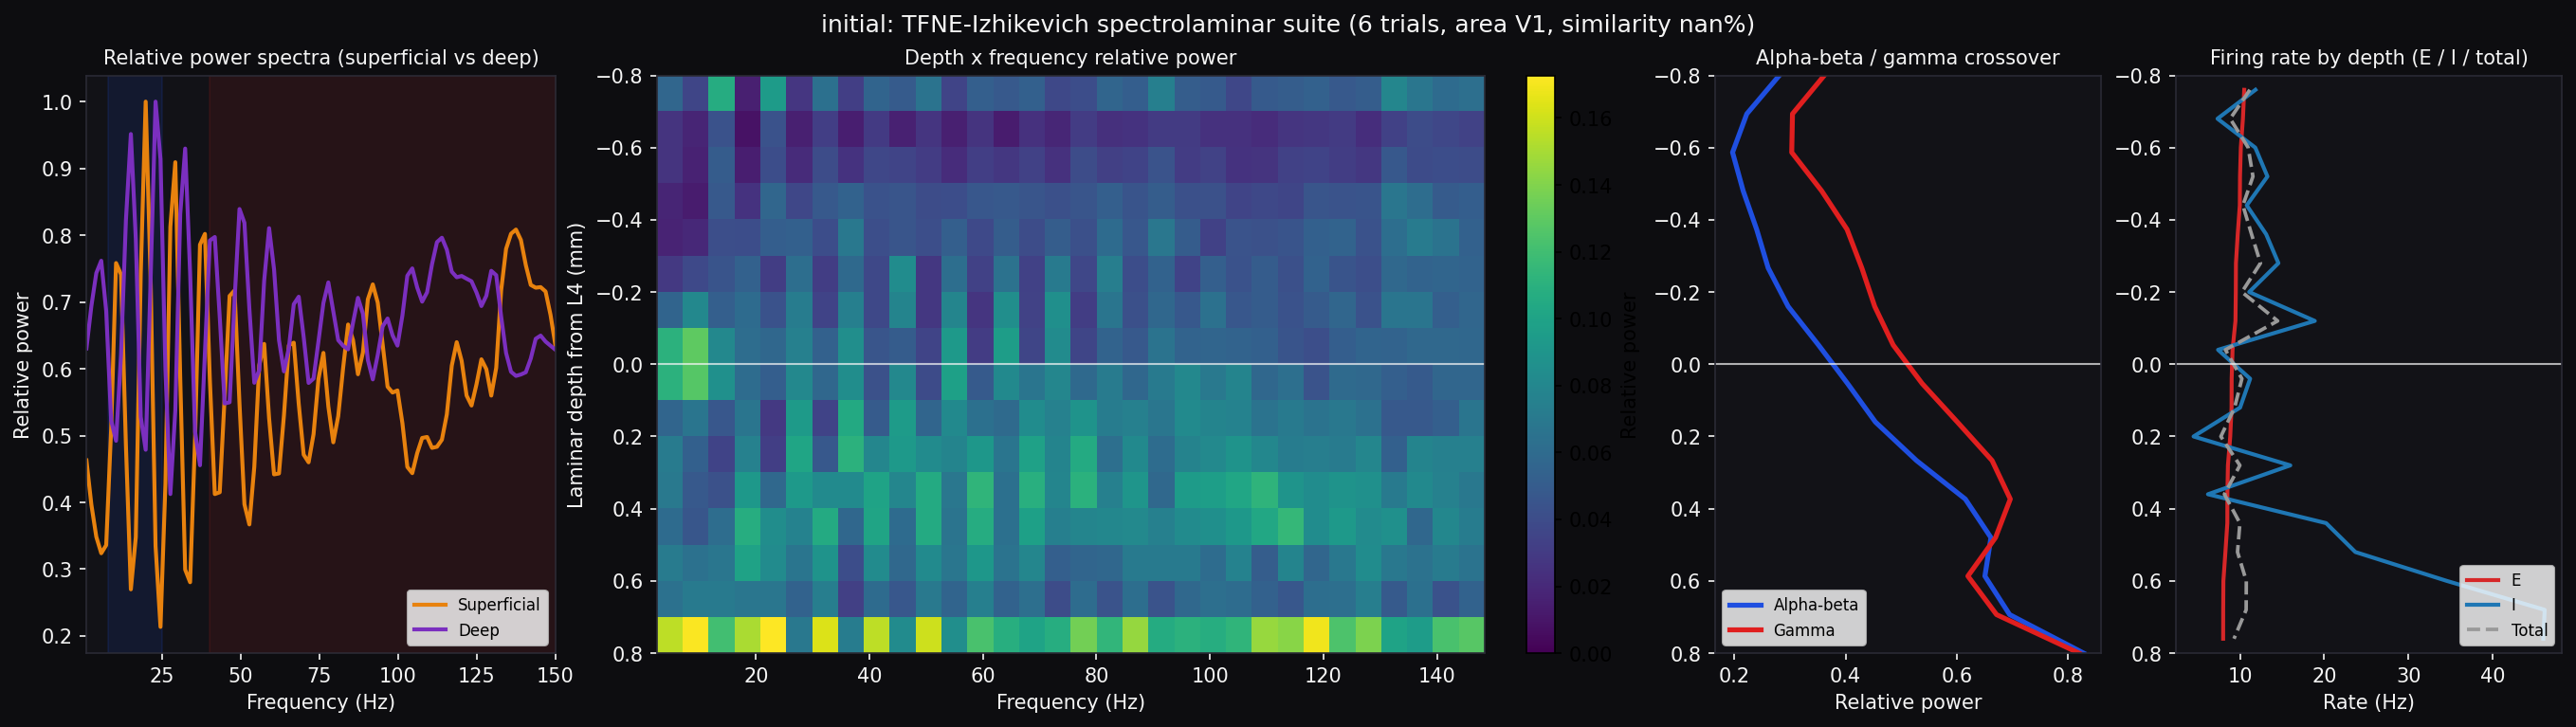

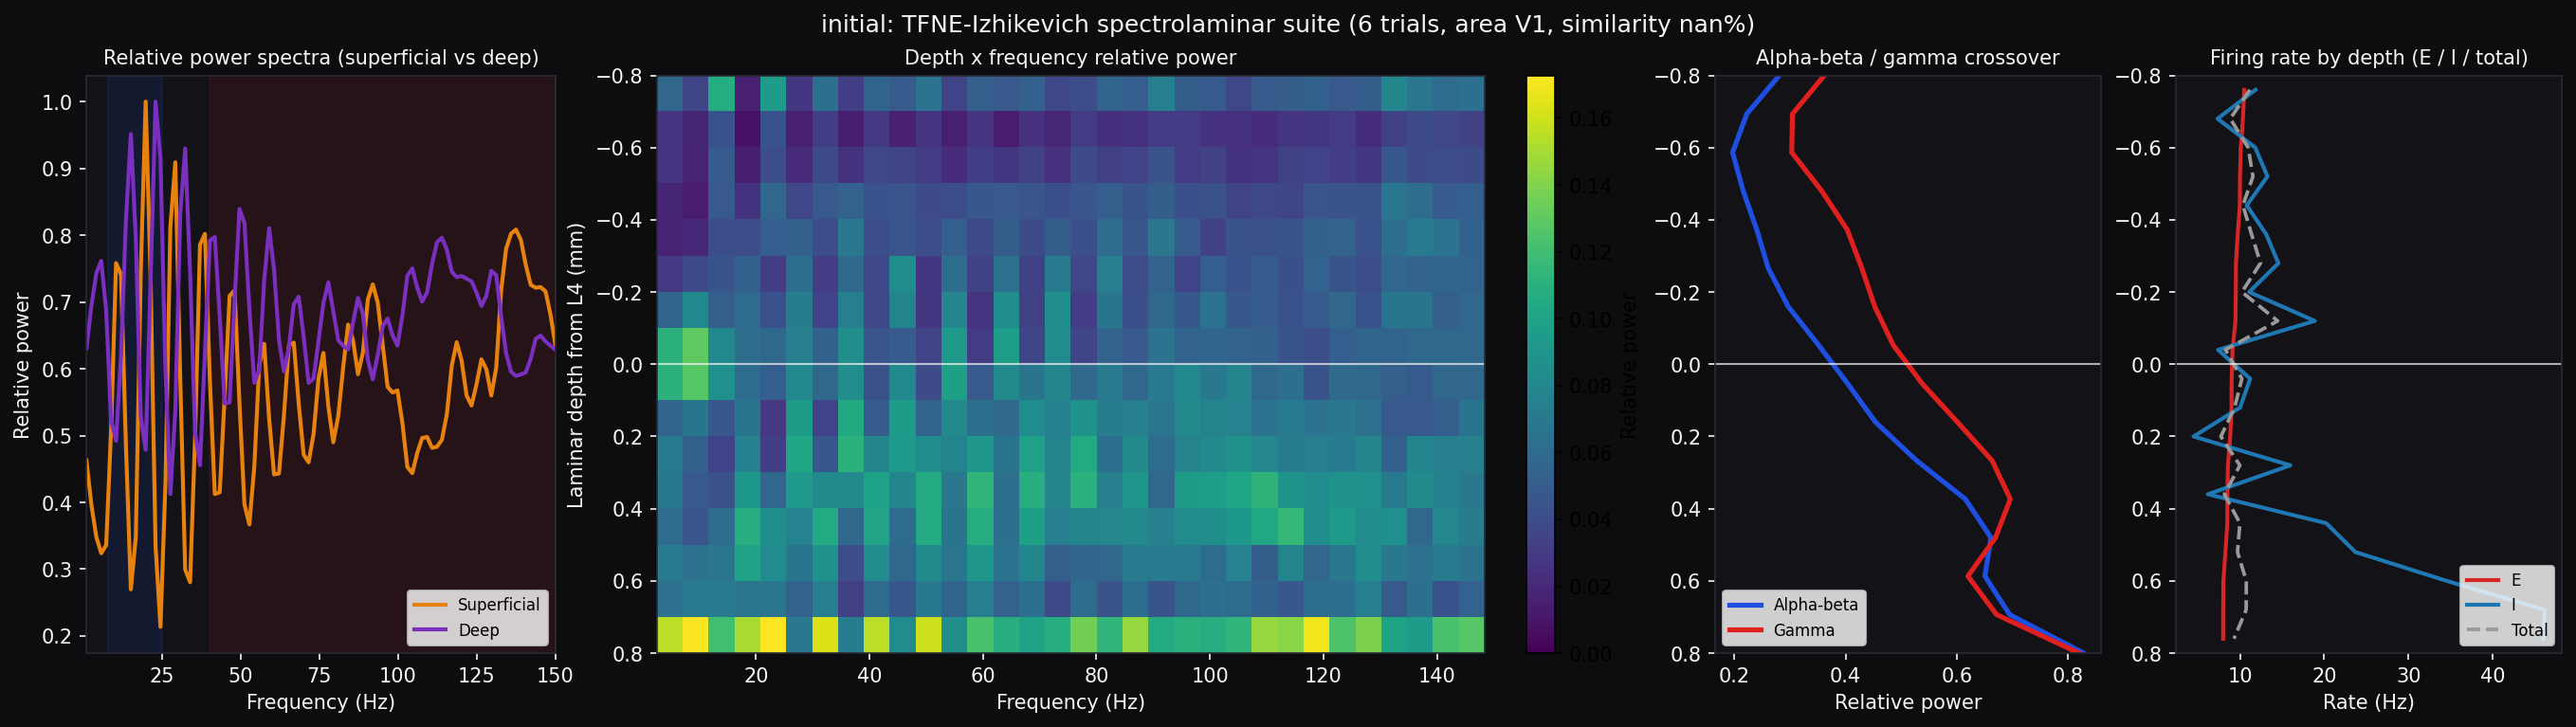

In [5]:
specfigs = jtfne.vis.spectrolaminar_suite_3panel(
    model, n_trials=N_TRIALS, duration_ms=DURATION_MS, dt_ms=DT_MS, seed=SEED,
    signal="csd", freq_min_hz=1.0, freq_max_hz=150.0, freq_count=96,
    alpha_beta_range_hz=ALPHA_BETA_HZ, gamma_range_hz=GAMMA_HZ)
from pathlib import Path
assets = Path("assets"); assets.mkdir(exist_ok=True)
for area, fig in specfigs.items():
    fig.savefig(assets / f"etude7_spectrolaminar_{area}.png", dpi=120, bbox_inches="tight")
print("spectrolaminar suite saved for areas:", list(specfigs.keys()))
list(specfigs.values())[0]

## 5 · Objective — band-localized power across depth

Quantify the motif: mean α/β and γ relative power in the superficial vs deep half
of the contacts (band power computed from the proxy field PSD).

In [6]:
field = sig.get("csd_proxy")                       # [T, n_contacts]
def bandpow(lo, hi):
    # Delegates to the package rfft band-power helper (rectangular
    # convention, identical bin summation to the previous inline code).
    return jtfne.tutorial_utils.absolute_band_power(field, DT_MS, lo, hi)
ab, ga = bandpow(*ALPHA_BETA_HZ), bandpow(*GAMMA_HZ)
nc = field.shape[1]; sup, deep = slice(0, nc // 2), slice(nc // 2, nc)
print(f"alpha/beta power  superficial={ab[sup].mean():.2e}  deep={ab[deep].mean():.2e}")
print(f"gamma      power  superficial={ga[sup].mean():.2e}  deep={ga[deep].mean():.2e}")
print(f"async-irregular gate (kappa<0.2): {'PASS' if kappa < 0.2 else 'FAIL'} (kappa={kappa:.3f})")

alpha/beta power  superficial=4.93e+07  deep=1.65e+08
gamma      power  superficial=7.79e+07  deep=1.90e+08
async-irregular gate (kappa<0.2): PASS (kappa=0.022)


## 6 · Export — manifest + figure artifacts

In [7]:
man = jtfne.manifest(cfg, signals=sig)
print("manifest config_hash:", man.get("config_hash"))
print("saved figures:", [p.name for p in sorted(assets.glob("etude7_*"))])

manifest config_hash: 53b25b45b0871729
saved figures: ['etude7_spectrolaminar_V1.png']


## Notes

- **Trust gate.** κ is reported every run; κ ≳ 0.2 means a global rhythm is biasing
  the readout and the depth × frequency profile should not be trusted.
- **Scale-emergent.** The deep-α/β vs superficial-γ crossover requires band-limited
  oscillations localized by layer and is present at scale (≈1k+), not at small N.
- **Projection.** Density-preserving (SUM) projection preserves laminar depth
  structure; row-normalization erases it.
- Computational scaffold; `*_proxy` readouts only. jaxfne is the mathematical
  backend — biophysical fidelity follows the configuration you provide.